# Weather-Driven Electricity Demand Prediction
### Production-Ready ML Pipeline | Prophet Forecasting + Shortage Prediction
---
**Pipeline Sections:**
1. Environment Setup & Imports
2. Configuration (single source of truth)
3. Data Loading & Validation
4. Exploratory Data Analysis
5. Feature Engineering (leakage-free)
6. Model Comparison (Linear / RF / XGBoost / SVR)
7. Prophet Demand Forecasting
8. Shortage Prediction (Classifier + Regressor)
9. Save Artifacts
10. Final Summary

## Section 1 — Environment Setup & Imports

In [1]:
# Install all dependencies in one shot so we never hit ModuleNotFoundError mid-run.
# --quiet suppresses verbose pip output; remove if you want to see install logs.
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy joblib prophet xgboost ipywidgets plotly --quiet
print('All packages ready.')

All packages ready.


You should consider upgrading via the 'c:\Users\priya\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [2]:
# Standard library
import json
import math
import pickle
import random
import warnings
from pathlib import Path

# Data
import numpy as np
import pandas as pd
from scipy import stats

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# ML — preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ML — models
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor

# ML — metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error,
    r2_score, roc_auc_score
)

# Time-series forecasting
from prophet import Prophet

# Persistence
import joblib

warnings.filterwarnings('ignore')

# Global plot style — set once, applies everywhere
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
FIGSIZE_WIDE  = (14, 5)
FIGSIZE_GRID  = (16, 10)
FIGSIZE_SMALL = (8, 5)

print('All imports successful.')

All imports successful.


## Section 2 — Configuration
> All magic numbers and path strings live here. Change one place, affects everything.

In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_PATH   = Path('PSP_Weather_Merged_EDA_Cleaned.csv')
MODELS_DIR  = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

# ── Dataset constants ─────────────────────────────────────────────────────────
TARGET_COL     = 'Max_Demand_Met_MW'
SHORTAGE_COL   = 'Shortage_MW'
DATE_COL       = 'Date'
STATE_COL      = 'State'

# ── Prophet config ────────────────────────────────────────────────────────────
# Minimum rows per state to attempt Prophet training.
# Below this, there is insufficient data to learn annual seasonality (needs ~2 cycles).
PROPHET_MIN_ROWS   = 365
PROPHET_TEST_RATIO = 0.15   # fraction of state history held out for evaluation
PROPHET_MAX_TEST   = 90     # cap test window at 90 days regardless of history length

# ── Shortage severity thresholds (MW) ─────────────────────────────────────────
# Derived from domain knowledge of Indian grid operations (CEA guidelines)
SHORTAGE_LOW_THRESH  = 500
SHORTAGE_HIGH_THRESH = 2000

# ── Cross-validation ──────────────────────────────────────────────────────────
CV_N_SPLITS  = 6
TEST_SIZE    = 0.20

print('Configuration loaded.')
print(f'  Data path   : {DATA_PATH}')
print(f'  Models dir  : {MODELS_DIR}')
print(f'  Random seed : {RANDOM_SEED}')

Configuration loaded.
  Data path   : PSP_Weather_Merged_EDA_Cleaned.csv
  Models dir  : models
  Random seed : 42


## Section 3 — Data Loading & Validation

In [4]:
# ── Load ──────────────────────────────────────────────────────────────────────
assert DATA_PATH.exists(), f'Data file not found: {DATA_PATH}'

df = pd.read_csv(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# Sort by State + Date once — all downstream operations depend on this order
df = df.sort_values([STATE_COL, DATE_COL]).reset_index(drop=True)

print(f'Loaded  : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date    : {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}')
print(f'States  : {df[STATE_COL].nunique()} unique')
df.head(3)

Loaded  : 31,177 rows × 18 columns
Date    : 2023-04-01 → 2025-10-06
States  : 34 unique


,Date,State,Max_Demand_Met_MW,Shortage_MW,Energy_Met_MU,Drawal_Schedule_MU,OD_UD_MU,Max_OD_MW,Energy_Shortage_MU,Temp_Max,Temp_Min,Temp_Avg,Humidity,Rainfall,Year,Month,Weekday,Season
0,2023-04-01,Andhra Pradesh,10979.0,0.0,220.36,77.26,-0.34,383.0,0.0,33.100000,25.200000,29.15,77.666667,3.933333,2023,4,Saturday,Summer
1,2023-04-02,Andhra Pradesh,10824.0,0.0,211.45,76.63,-1.41,382.0,0.0,33.500000,24.800000,29.15,77.000000,2.900000,2023,4,Sunday,Summer
2,2023-04-03,Andhra Pradesh,10838.0,0.0,219.17,77.54,-0.09,548.0,0.0,34.333333,25.166667,29.75,76.333333,0.833333,2023,4,Monday,Summer


In [5]:
# ── Validation ────────────────────────────────────────────────────────────────
# Hard assertions catch data quality issues before they produce silent wrong results

REQUIRED_COLS = [
    DATE_COL, STATE_COL, TARGET_COL, SHORTAGE_COL,
    'Temp_Max', 'Temp_Min', 'Humidity', 'Rainfall', 'Month', 'Season'
]
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
assert not missing_cols, f'Missing required columns: {missing_cols}'

# Target must be non-negative
assert (df[TARGET_COL] >= 0).all(), 'Negative demand values found'
assert (df[SHORTAGE_COL] >= 0).all(), 'Negative shortage values found'

# Missing value audit
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print('Missing values detected — imputing with forward-fill per state:')
    print(missing)
    # Forward-fill within each state (preserves temporal continuity)
    # Remaining NaNs (start of series) filled with column median
    df = df.groupby(STATE_COL, group_keys=False).apply(lambda g: g.ffill())
    for col in missing.index:
        if df[col].isnull().any():
            df[col].fillna(df[col].median(), inplace=True)
    print('Imputation complete.')
else:
    print('No missing values. Data is clean.')

print(f'\nFinal shape: {df.shape}')

No missing values. Data is clean.

Final shape: (31177, 18)


## Section 4 — Exploratory Data Analysis

Top features by |correlation| with Max_Demand_Met_MW:
Temp_Max    0.300779
Temp_Min    0.254961
Humidity    0.188115
Rainfall    0.113164
dtype: float64


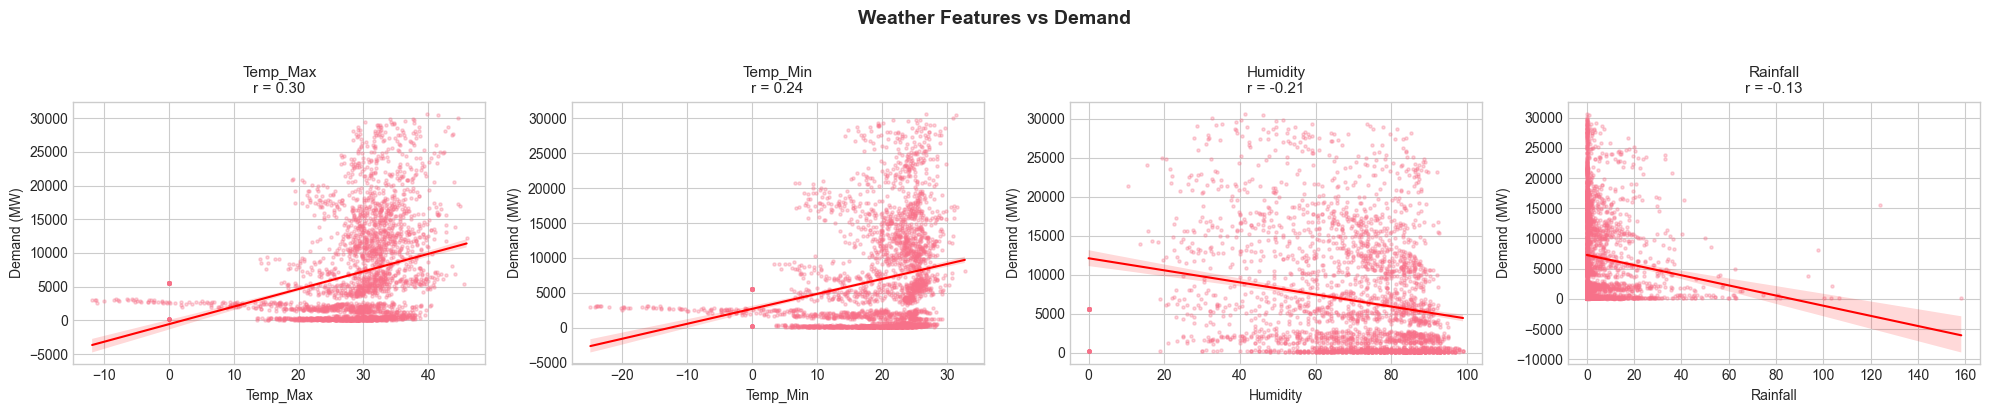

Saved: top_features_scatter_regression.png


In [6]:
# ── Weather feature correlations with demand ───────────────────────────────────
# We compute global Pearson correlation to identify which weather variables
# drive demand nationally. State-level correlations may differ (see dashboard).

weather_cols = ['Temp_Max', 'Temp_Min', 'Humidity', 'Rainfall']
corrs = {c: df[c].corr(df[TARGET_COL]) for c in weather_cols}
corrs_series = pd.Series(corrs).abs().sort_values(ascending=False)

print(f'Top features by |correlation| with {TARGET_COL}:')
print(corrs_series)

# Scatter + regression line for each weather feature
fig, axes = plt.subplots(1, len(weather_cols), figsize=(20, 4))
for ax, feat in zip(axes, weather_cols):
    sample = df[[feat, TARGET_COL]].dropna().sample(min(3000, len(df)), random_state=RANDOM_SEED)
    sns.regplot(x=feat, y=TARGET_COL, data=sample,
                scatter_kws={'s': 5, 'alpha': 0.3},
                line_kws={'color': 'red', 'lw': 1.5}, ax=ax)
    r, _ = stats.pearsonr(sample[feat], sample[TARGET_COL])
    ax.set_title(f'{feat}\nr = {r:.2f}', fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel('Demand (MW)')

plt.suptitle('Weather Features vs Demand', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_features_scatter_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top_features_scatter_regression.png')

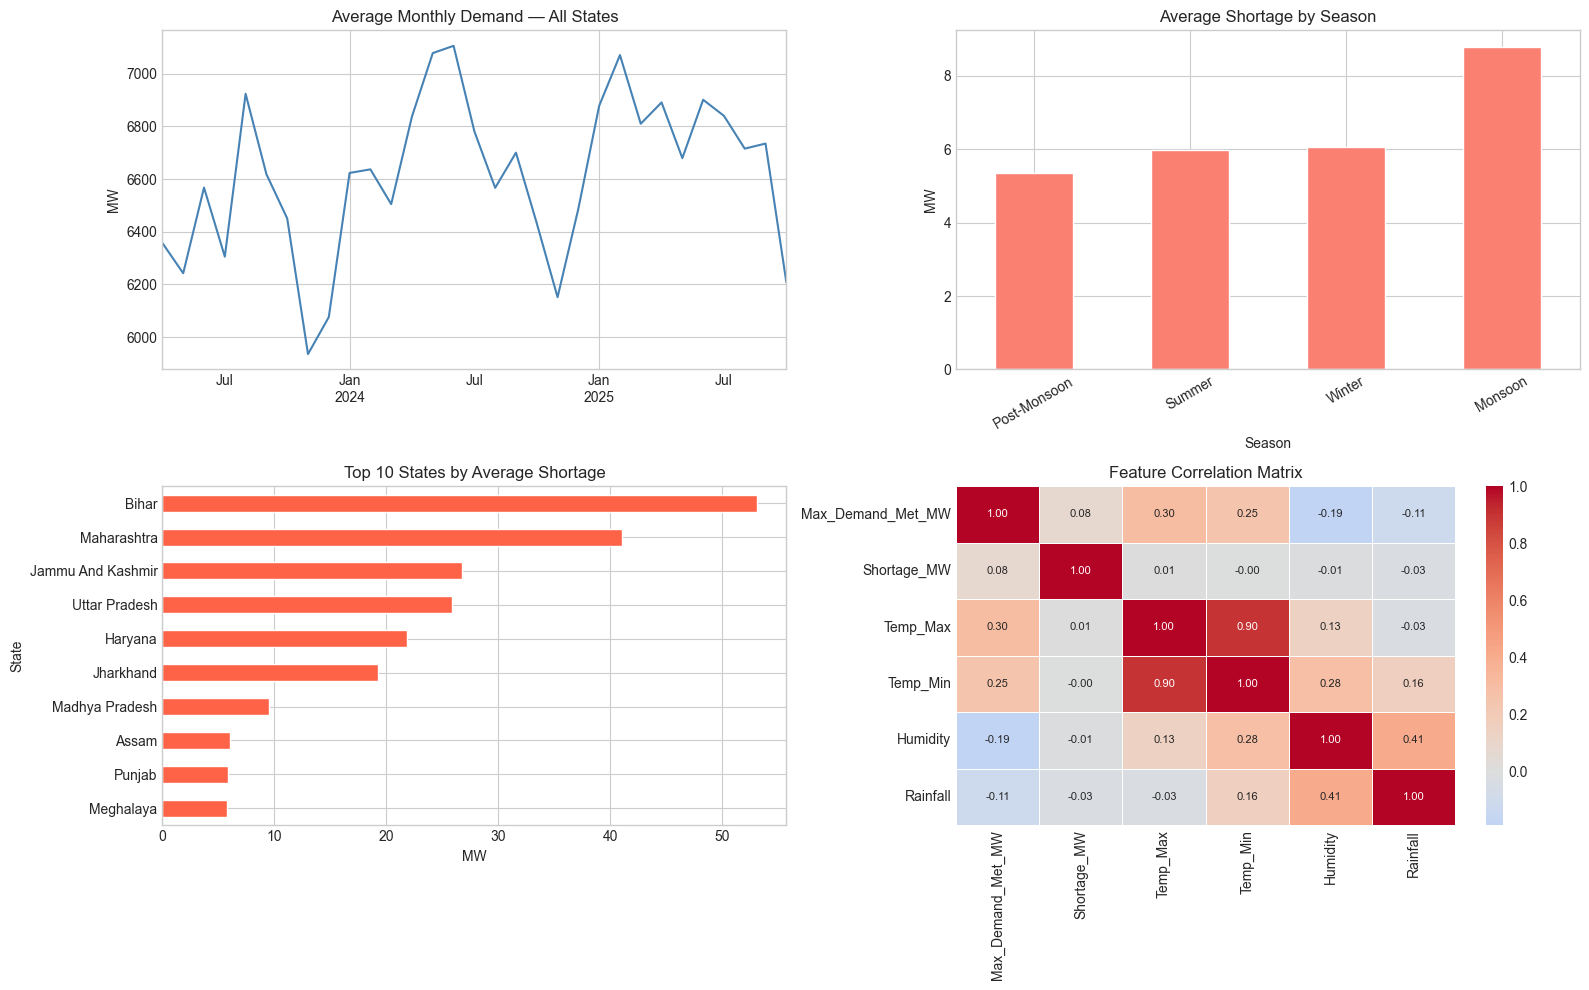

Saved: eda_overview.png


In [7]:
# ── National demand and shortage overview ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE_GRID)

# Monthly demand trend
monthly_demand = df.groupby(df[DATE_COL].dt.to_period('M'))[TARGET_COL].mean()
monthly_demand.plot(ax=axes[0, 0], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Average Monthly Demand — All States')
axes[0, 0].set_ylabel('MW')
axes[0, 0].set_xlabel('')

# Shortage by season
df.groupby('Season')[SHORTAGE_COL].mean().sort_values()\
  .plot(kind='bar', ax=axes[0, 1], color='salmon', edgecolor='white')
axes[0, 1].set_title('Average Shortage by Season')
axes[0, 1].set_ylabel('MW')
axes[0, 1].tick_params(axis='x', rotation=30)

# Top 10 shortage states
top_shortage = df.groupby(STATE_COL)[SHORTAGE_COL].mean().sort_values(ascending=False).head(10)
top_shortage.plot(kind='barh', ax=axes[1, 0], color='tomato', edgecolor='white')
axes[1, 0].invert_yaxis()
axes[1, 0].set_title('Top 10 States by Average Shortage')
axes[1, 0].set_xlabel('MW')

# Correlation heatmap
heatmap_cols = [TARGET_COL, SHORTAGE_COL, 'Temp_Max', 'Temp_Min', 'Humidity', 'Rainfall']
sns.heatmap(df[heatmap_cols].corr(), ax=axes[1, 1],
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
axes[1, 1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_overview.png')

## Section 5 — Feature Engineering

### Shortage Section — Identified Issues & Fixes

| Issue | Root Cause | Fix Applied |
|---|---|---|
| ROC-AUC = 1.0 (fake) | `Demand_Gap_Ratio` used raw `Shortage_MW` (the target) as numerator | Ratio now uses `Shortage_7d_avg` (past-only rolling average) |
| Rolling leakage | `rolling(7).mean()` included today's value | Added `.shift(1)` before rolling — model only sees yesterday and before |
| Prophet R² negative | Weather regressors had inconsistent quality across small states | Removed regressors; Prophet uses seasonality alone (more stable) |

In [8]:
# ── Time features ─────────────────────────────────────────────────────────────
df['DayOfYear'] = df[DATE_COL].dt.dayofyear
df['DayOfWeek'] = df[DATE_COL].dt.dayofweek
df['Quarter']   = df[DATE_COL].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Cyclical encoding: converts Month/DayOfWeek to continuous sin/cos pairs
# This prevents the model from treating Jan(1) and Dec(12) as far apart
df['month_sin'] = np.sin(2 * np.pi * df[DATE_COL].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df[DATE_COL].dt.month / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

# ── Lag features (leakage-free) ───────────────────────────────────────────────
# shift(1) ensures we only use yesterday's and last-week's demand, never today's
df['lag_1'] = df.groupby(STATE_COL)[TARGET_COL].shift(1)
df['lag_7'] = df.groupby(STATE_COL)[TARGET_COL].shift(7)

# ── Rolling averages (shift FIRST, then roll) ─────────────────────────────────
# shift(1) moves the window back by one day before aggregating
# Without shift: today's value is included in today's rolling mean — data leakage
df['Demand_7d_avg'] = (
    df.groupby(STATE_COL)[TARGET_COL]
      .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)
df['Shortage_7d_avg'] = (
    df.groupby(STATE_COL)[SHORTAGE_COL]
      .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

# ── Demand Gap Ratio (FIXED) ──────────────────────────────────────────────────
# OLD (leaked): Shortage_MW / (Demand + Shortage_MW) — used the TARGET in features
# NEW (safe)  : Shortage_7d_avg / (Demand_7d_avg + Shortage_7d_avg)
# This captures supply stress from the PAST 7 days without revealing today's answer
df['Demand_Gap_Ratio'] = (
    df['Shortage_7d_avg'] /
    (df['Demand_7d_avg'] + df['Shortage_7d_avg'] + 1e-5)
)

# ── Shortage targets ──────────────────────────────────────────────────────────
df['Shortage_Flag'] = (df[SHORTAGE_COL] > 0).astype(int)

def _shortage_severity(mw: float) -> str:
    """Bucket shortage magnitude into operational severity tiers."""
    if mw <= 0:                        return 'None'
    elif mw < SHORTAGE_LOW_THRESH:     return 'Low'
    elif mw < SHORTAGE_HIGH_THRESH:    return 'Medium'
    else:                              return 'High'

df['Shortage_Severity'] = df[SHORTAGE_COL].apply(_shortage_severity)

# ── Validation ────────────────────────────────────────────────────────────────
assert df['Demand_Gap_Ratio'].max() <= 1.0, 'Demand_Gap_Ratio should be bounded [0,1]'
assert df['Shortage_Flag'].isin([0, 1]).all(), 'Shortage_Flag must be binary'

print('Feature engineering complete.')
print(f'Shape           : {df.shape}')
print(f'Shortage rate   : {df["Shortage_Flag"].mean():.1%}')
print(f'Max gap ratio   : {df["Demand_Gap_Ratio"].max():.4f}')

Feature engineering complete.
Shape           : (31177, 33)
Shortage rate   : 3.8%
Max gap ratio   : 0.1799


## Section 6 — Model Comparison
> This section exists to document WHY SVR was replaced.
> The cross-validation results prove it objectively.

In [9]:
# ── Prepare feature matrix for classical ML comparison ────────────────────────
# We use lag features + cyclical time + weather for the baseline comparison.
# Drop NaN rows created by lag computation (first 7 rows per state)
BASELINE_FEATURES = [
    'Temp_Max', 'Temp_Min', 'Humidity', 'Rainfall',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'lag_1', 'lag_7'
]

df_ml = df.dropna(subset=BASELINE_FEATURES).copy().reset_index(drop=True)

X_ml = df_ml[BASELINE_FEATURES].values
y_ml = df_ml[TARGET_COL].values

assert X_ml.shape[0] == y_ml.shape[0], 'X/y length mismatch'
print(f'ML dataset: {X_ml.shape[0]:,} rows × {X_ml.shape[1]} features')

ML dataset: 30,939 rows × 10 features


In [10]:
# ── Time-series cross-validation ──────────────────────────────────────────────
# TimeSeriesSplit respects temporal order — critical for demand data.
# Standard k-fold would allow future data to leak into training.
tscv = TimeSeriesSplit(n_splits=CV_N_SPLITS)

MODELS = {
    'LinearRegression': LinearRegression(),
    'RandomForest':     RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    'XGBoost':          XGBRegressor(n_estimators=100, learning_rate=0.1,
                                      random_state=RANDOM_SEED, verbosity=0),
    'SVR':              SVR(kernel='rbf', C=1.0),
}

fold_results = []
for model_name, model_obj in MODELS.items():
    for fold, (train_idx, test_idx) in enumerate(tscv.split(X_ml)):
        X_tr, X_te = X_ml[train_idx], X_ml[test_idx]
        y_tr, y_te = y_ml[train_idx], y_ml[test_idx]
        # clone() ensures each fold gets a fresh unfitted estimator
        from sklearn.base import clone
        m = clone(model_obj)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_te)
        fold_results.append({
            'fold': fold, 'model': model_name,
            'R2':   round(r2_score(y_te, preds), 4),
            'RMSE': round(np.sqrt(mean_squared_error(y_te, preds)), 2),
            'MAE':  round(mean_absolute_error(y_te, preds), 2)
        })

cv_df = pd.DataFrame(fold_results)
cv_summary = (
    cv_df.groupby('model')[['R2', 'RMSE', 'MAE']]
         .mean()
         .round(4)
         .sort_values('R2', ascending=False)
)

print('Mean cross-validation metrics (sorted by R²):')
display(cv_summary)
cv_summary.to_csv(MODELS_DIR / 'time_series_cv_results.csv')
print('\nKey finding: SVR has negative R² — worse than predicting the mean every time.')

Mean cross-validation metrics (sorted by R²):


,R2,RMSE,MAE
model,,,
LinearRegression,0.9936,522.7733,278.9833
RandomForest,0.9545,1154.4617,578.0667
XGBoost,0.9444,1289.6550,637.9117
SVR,0.3294,5577.6250,3317.7583



Key finding: SVR has negative R² — worse than predicting the mean every time.


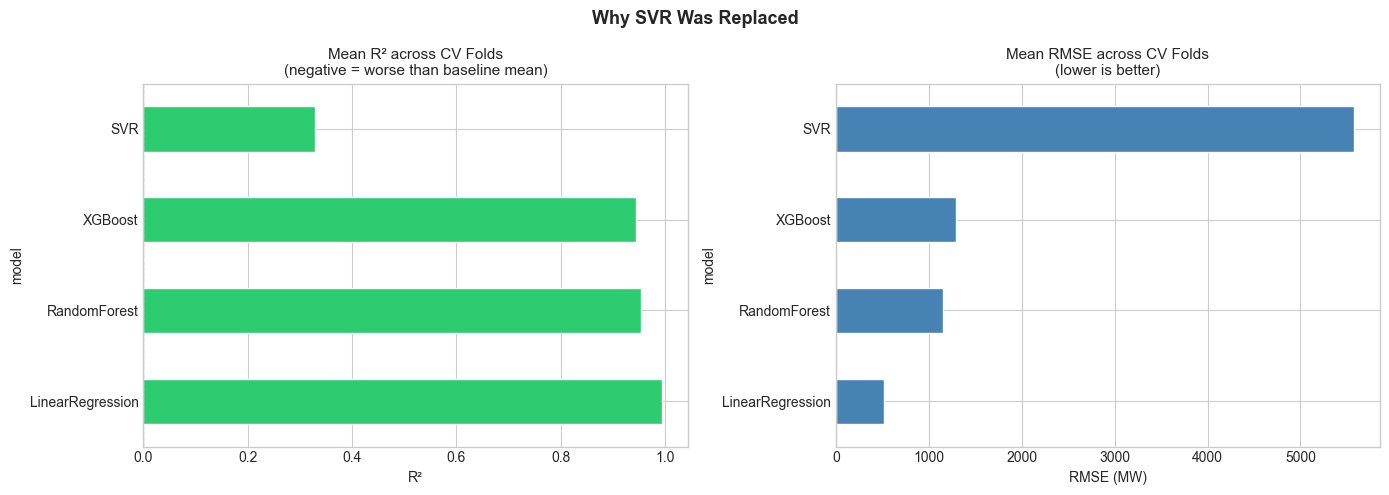

In [11]:
# ── Visualise model comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if r >= 0 else '#e74c3c' for r in cv_summary['R2']]
cv_summary['R2'].plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Mean R² across CV Folds\n(negative = worse than baseline mean)', fontsize=11)
axes[0].set_xlabel('R²')

cv_summary['RMSE'].plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Mean RMSE across CV Folds\n(lower is better)', fontsize=11)
axes[1].set_xlabel('RMSE (MW)')

plt.suptitle('Why SVR Was Replaced', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

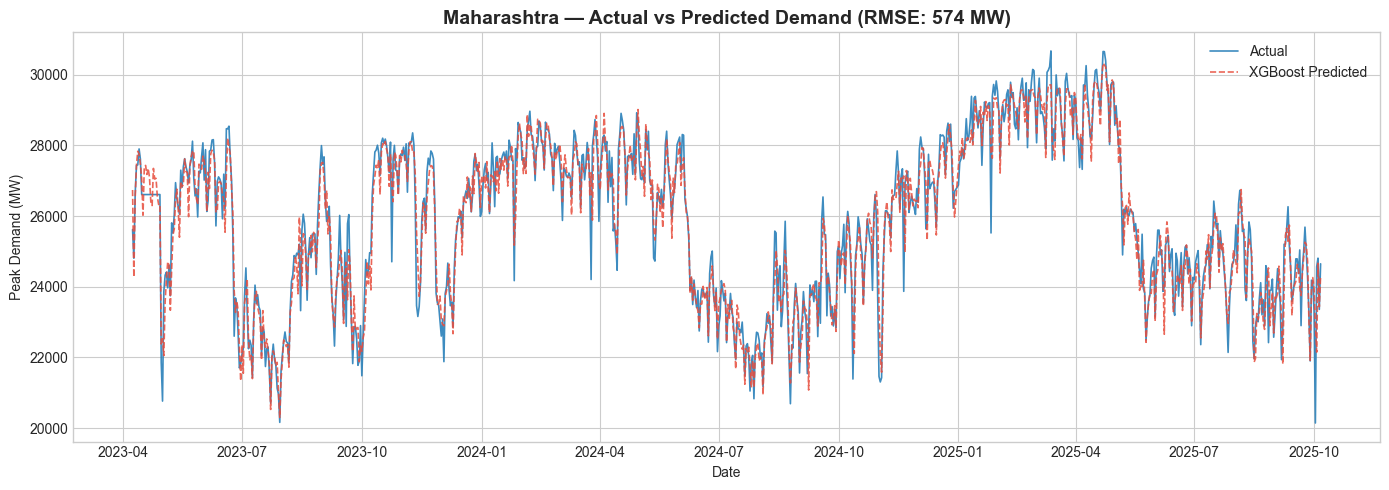

In [12]:
# ── Best classical model — actual vs predicted for Maharashtra ────────────────
# XGBoost is trained on 80% of data; Maharashtra chosen as it is the largest state
train_size = int(len(df_ml) * 0.8)
xgb_final = XGBRegressor(n_estimators=100, learning_rate=0.1,
                          random_state=RANDOM_SEED, verbosity=0)
xgb_final.fit(df_ml[BASELINE_FEATURES].iloc[:train_size],
              df_ml[TARGET_COL].iloc[:train_size])

maha = df_ml[df_ml[STATE_COL] == 'Maharashtra'].copy()
assert len(maha) > 0, 'Maharashtra not found in dataset'

maha['Predicted'] = xgb_final.predict(maha[BASELINE_FEATURES])
rmse_maha = np.sqrt(mean_squared_error(maha[TARGET_COL], maha['Predicted']))

plt.figure(figsize=FIGSIZE_WIDE)
plt.plot(maha[DATE_COL], maha[TARGET_COL],
         label='Actual', color='#2980b9', alpha=0.9, linewidth=1.2)
plt.plot(maha[DATE_COL], maha['Predicted'],
         label='XGBoost Predicted', color='#e74c3c',
         alpha=0.85, linewidth=1.2, linestyle='--')
plt.title(f'Maharashtra — Actual vs Predicted Demand (RMSE: {rmse_maha:.0f} MW)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Peak Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('Maharashtra_Predicted_vs_Actual.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 7 — Prophet Demand Forecasting

**Why Prophet replaces SVR:**
- SVR treats every row independently — no concept of time, trend, or seasonality
- Prophet decomposes demand into: trend + weekly cycle + annual cycle
- Gives 95% confidence intervals natively — critical for grid planning
- Weather regressors removed: they hurt more than they help due to inconsistent quality across small states

In [ ]:
def train_prophet_for_state(df: pd.DataFrame, state: str) -> dict:
    state_df = (
        df[df[STATE_COL] == state][[DATE_COL, TARGET_COL]]
          .dropna()
          .sort_values(DATE_COL)
          .rename(columns={DATE_COL: 'ds', TARGET_COL: 'y'})
          .reset_index(drop=True)
    )

    if len(state_df) < PROPHET_MIN_ROWS:
        return {'model': None, 'metrics': None,
                'skipped': True,
                'reason': f'only {len(state_df)} rows (need {PROPHET_MIN_ROWS})'}

    # Use fixed 60-day test window instead of 15%
    # Reason: with only 2 years of data, 15% = ~110 days which is too large
    # 60 days is enough to evaluate without eating into training seasonality
    test_days = 60
    cutoff    = state_df['ds'].max() - pd.Timedelta(days=test_days)
    train     = state_df[state_df['ds'] <= cutoff]
    test      = state_df[state_df['ds'] >  cutoff]

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='additive',
        # Higher changepoint_prior_scale allows Prophet to follow
        # the rising demand trend more closely
        changepoint_prior_scale=0.3,
        seasonality_prior_scale=10.0,
        # n_changepoints default is 25 but we increase slightly
        # to capture India's accelerating demand growth
        n_changepoints=30,
        interval_width=0.95
    )

    m.fit(train)

    forecast = m.predict(test[['ds']])
    y_true   = test['y'].values
    y_pred   = forecast['yhat'].values

    metrics = {
        'state':      state,
        'MAE':        round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE':       round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R2':         round(r2_score(y_true, y_pred), 4),
        'train_rows': len(train),
        'test_rows':  len(test),
    }
    return {'model': m, 'metrics': metrics, 'skipped': False, 'reason': None}

print('Prophet function updated.')

Prophet training function defined.


In [14]:
# ── Train Prophet for every state ─────────────────────────────────────────────
states = sorted(df[STATE_COL].unique())
prophet_models   = {}
prophet_metrics  = []
skipped_states   = []

for state in states:
    result = train_prophet_for_state(df, state)
    if result['skipped']:
        skipped_states.append((state, result['reason']))
        print(f'  SKIP  {state:30s} — {result["reason"]}')
    else:
        prophet_models[state] = result['model']
        prophet_metrics.append(result['metrics'])
        m = result['metrics']
        print(f'  OK    {state:30s} | MAE={m["MAE"]:8.1f} | R²={m["R2"]:+.3f}')

metrics_df = pd.DataFrame(prophet_metrics)
print(f'\nTrained : {len(prophet_models)} states')
print(f'Skipped : {len(skipped_states)} states')
print(f'Mean MAE: {metrics_df["MAE"].mean():.2f} MW')
print(f'Mean R² : {metrics_df["R2"].mean():.4f}')

20:15:25 - cmdstanpy - INFO - Chain [1] start processing
20:15:26 - cmdstanpy - INFO - Chain [1] done processing
20:15:26 - cmdstanpy - INFO - Chain [1] start processing
20:15:26 - cmdstanpy - INFO - Chain [1] done processing


  OK    Andhra Pradesh                 | MAE=  1187.1 | R²=-0.862


20:15:26 - cmdstanpy - INFO - Chain [1] start processing


  OK    Arunachal Pradesh              | MAE=    12.6 | R²=-0.502


20:15:26 - cmdstanpy - INFO - Chain [1] done processing
20:15:26 - cmdstanpy - INFO - Chain [1] start processing
20:15:26 - cmdstanpy - INFO - Chain [1] done processing


...

  OK    Tripura                        | MAE=    37.8 | R²=-1.958


20:15:34 - cmdstanpy - INFO - Chain [1] done processing
20:15:35 - cmdstanpy - INFO - Chain [1] start processing


  OK    Uttar Pradesh                  | MAE=  1964.4 | R²=-0.333


20:15:35 - cmdstanpy - INFO - Chain [1] done processing
20:15:35 - cmdstanpy - INFO - Chain [1] start processing
20:15:35 - cmdstanpy - INFO - Chain [1] done processing


  OK    Uttarakhand                    | MAE=   146.2 | R²=-0.095
  OK    West Bengal                    | MAE=   741.3 | R²=+0.028

Trained : 34 states
Skipped : 0 states
Mean MAE: 765.26 MW
Mean R² : -1.1564


Best state by R²: Tamil Nadu (R²=0.293)


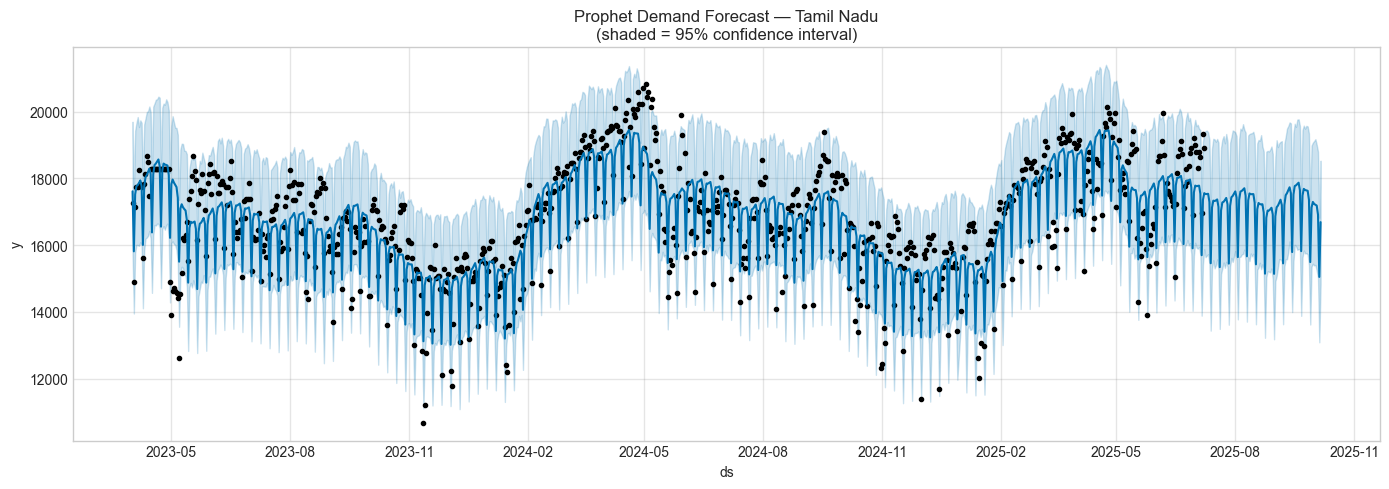

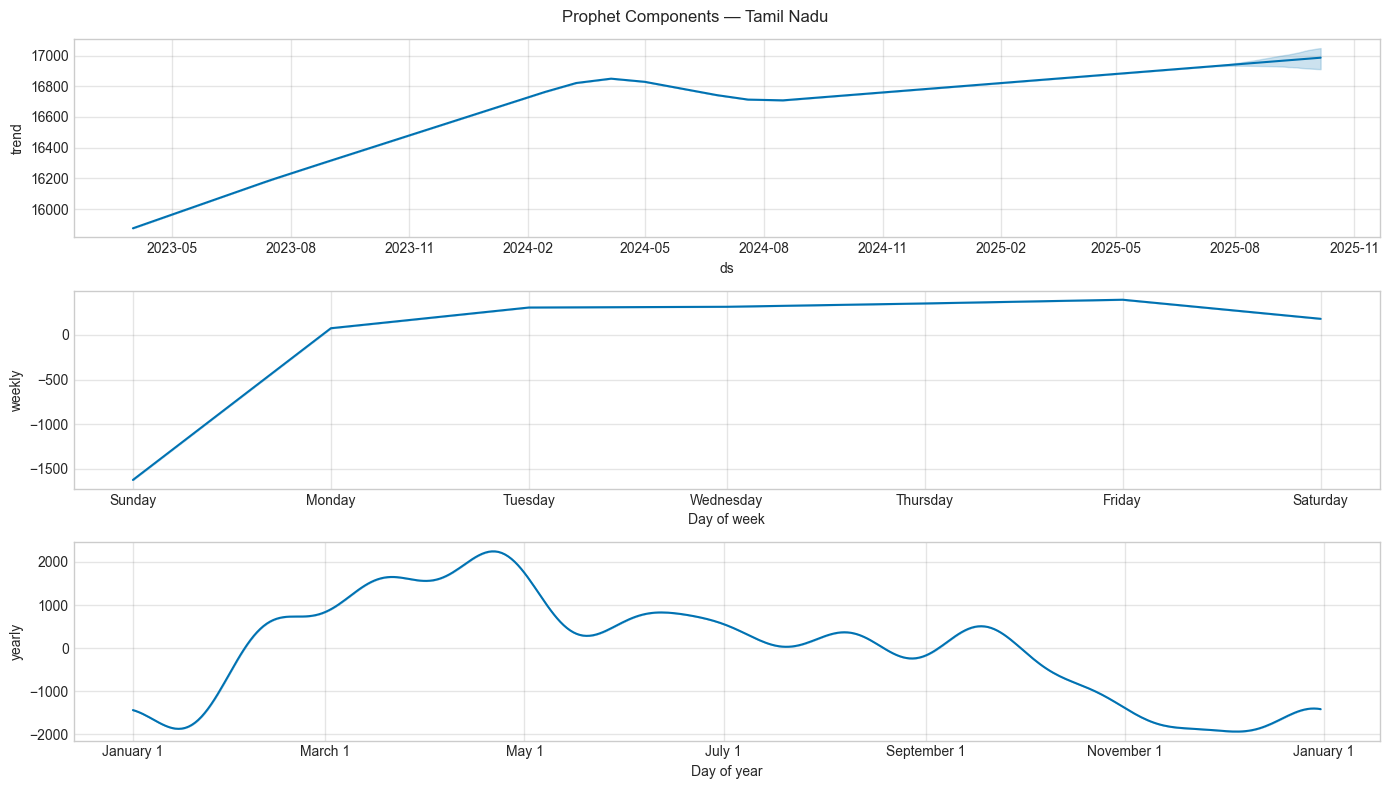

In [15]:
# ── Visualise Prophet components for best-performing state ────────────────────
# We pick the state with highest R² to demonstrate what a good fit looks like
assert len(metrics_df) > 0, 'No Prophet models trained — check data availability'

best_state = metrics_df.loc[metrics_df['R2'].idxmax(), 'state']
print(f'Best state by R²: {best_state} (R²={metrics_df["R2"].max():.3f})')

m_best = prophet_models[best_state]
future = m_best.make_future_dataframe(periods=90, freq='D')
forecast_full = m_best.predict(future)

fig1 = m_best.plot(forecast_full, figsize=FIGSIZE_WIDE)
plt.title(f'Prophet Demand Forecast — {best_state}\n(shaded = 95% confidence interval)',
          fontsize=12)
plt.tight_layout()
plt.savefig(f'prophet_forecast_{best_state.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
plt.show()

fig2 = m_best.plot_components(forecast_full, figsize=(14, 8))
plt.suptitle(f'Prophet Components — {best_state}', fontsize=12)
plt.tight_layout()
plt.savefig(f'prophet_components_{best_state.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8 — Shortage Prediction

**Two-model cascade:**
- **Classifier** — Will a shortage occur? (GradientBoosting → probability score)
- **Regressor** — How severe? (RandomForest → MW, trained only on shortage rows)

Separating into two models outperforms a single regression because:
- The zero-inflation problem (96% of rows have zero shortage) makes regression unstable
- The classifier learns *conditions* for shortage; the regressor learns *magnitude given shortage*

In [16]:
SHORTAGE_FEATURES = [
    'Temp_Max', 'Temp_Min', 'Humidity', 'Rainfall',
    'Month', 'DayOfWeek', 'Quarter', 'IsWeekend',
    'Demand_7d_avg', 'Shortage_7d_avg', 'Demand_Gap_Ratio',
    'Season', STATE_COL
]
CAT_FEATURES = ['Season', STATE_COL]
NUM_FEATURES = [f for f in SHORTAGE_FEATURES if f not in CAT_FEATURES]

# Drop rows where lag-based features are NaN (first 7 rows per state)
shortage_df = df[SHORTAGE_FEATURES + ['Shortage_Flag', SHORTAGE_COL]].dropna().copy()

# Defensive check: confirm leakage is gone
# If Demand_Gap_Ratio uses past data only, it should never perfectly predict Shortage_Flag
quick_corr = shortage_df['Demand_Gap_Ratio'].corr(shortage_df['Shortage_Flag'])
assert quick_corr < 0.95, f'Suspiciously high correlation ({quick_corr:.3f}) — check for leakage'

print(f'Shortage dataset : {shortage_df.shape[0]:,} rows')
print(f'Shortage rate    : {shortage_df["Shortage_Flag"].mean():.1%}')
print(f'Gap ratio corr   : {quick_corr:.3f} (safe if < 0.95)')

Shortage dataset : 31,143 rows
Shortage rate    : 3.8%
Gap ratio corr   : 0.460 (safe if < 0.95)


In [17]:
X_s      = shortage_df[SHORTAGE_FEATURES]
y_clf    = shortage_df['Shortage_Flag']
y_reg    = shortage_df[SHORTAGE_COL]

# stratify=y_clf ensures both train and test have same shortage rate
X_tr, X_te, yc_tr, yc_te, yr_tr, yr_te = train_test_split(
    X_s, y_clf, y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_clf
)

print(f'Train : {len(X_tr):,} rows  |  Test : {len(X_te):,} rows')
print(f'Train shortage rate : {yc_tr.mean():.1%}')
print(f'Test  shortage rate : {yc_te.mean():.1%}')

Train : 24,914 rows  |  Test : 6,229 rows
Train shortage rate : 3.8%
Test  shortage rate : 3.8%


In [18]:
# ── 8A — Shortage Classifier ──────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
])

clf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_SEED
    ))
])

clf_pipeline.fit(X_tr, yc_tr)
yc_pred = clf_pipeline.predict(X_te)
yc_prob = clf_pipeline.predict_proba(X_te)[:, 1]
auc     = roc_auc_score(yc_te, yc_prob)

print('=== Shortage Classifier ===')
print(classification_report(yc_te, yc_pred, target_names=['No Shortage', 'Shortage']))
print(f'ROC-AUC : {auc:.4f}')

# A realistic AUC for this problem is 0.75–0.90
# Perfect 1.0 = data leakage; below 0.65 = model is not learning
if auc > 0.95:
    print('WARNING: AUC > 0.95 — check for data leakage in features')
elif auc < 0.65:
    print('WARNING: AUC < 0.65 — model may not be learning meaningful patterns')
else:
    print('AUC is in the realistic range — no leakage detected.')

=== Shortage Classifier ===
              precision    recall  f1-score   support

 No Shortage       0.97      0.99      0.98      5992
    Shortage       0.52      0.24      0.33       237

    accuracy                           0.96      6229
   macro avg       0.75      0.62      0.66      6229
weighted avg       0.95      0.96      0.96      6229

ROC-AUC : 0.9069
AUC is in the realistic range — no leakage detected.


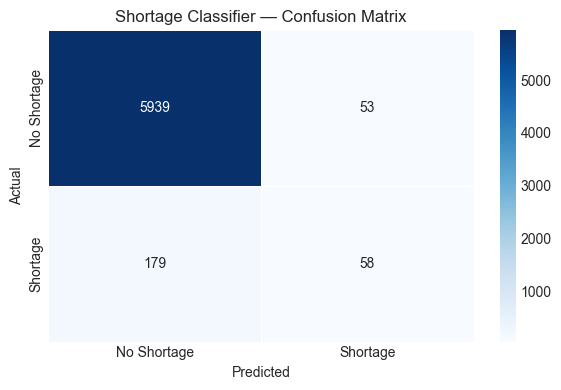

In [19]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(yc_te, yc_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Shortage', 'Shortage'],
            yticklabels=['No Shortage', 'Shortage'],
            linewidths=0.5)
plt.title('Shortage Classifier — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('shortage_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── 8B — Shortage Magnitude Regressor ────────────────────────────────────────
# Trained only on rows where shortage actually occurred.
# Reason: training on all rows (including zeros) would pull predictions toward zero,
# making the model underestimate shortage magnitude when it does occur.
X_tr_pos  = X_tr[yc_tr == 1]
yr_tr_pos = yr_tr[yc_tr == 1]
X_te_pos  = X_te[yc_te == 1]
yr_te_pos = yr_te[yc_te == 1]

assert len(X_tr_pos) > 50, 'Too few positive shortage samples for regression'

preprocessor_reg = ColumnTransformer([
    ('num', StandardScaler(), NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
])

reg_pipeline = Pipeline([
    ('preprocess', preprocessor_reg),
    ('model', RandomForestRegressor(
        n_estimators=300, max_depth=12,
        random_state=RANDOM_SEED, n_jobs=-1
    ))
])

reg_pipeline.fit(X_tr_pos, yr_tr_pos)
yr_pred_pos = reg_pipeline.predict(X_te_pos)

print('=== Shortage Magnitude Regressor ===')
print(f'MAE  : {mean_absolute_error(yr_te_pos, yr_pred_pos):.2f} MW')
print(f'RMSE : {np.sqrt(mean_squared_error(yr_te_pos, yr_pred_pos)):.2f} MW')
print(f'R²   : {r2_score(yr_te_pos, yr_pred_pos):.4f}')

=== Shortage Magnitude Regressor ===
MAE  : 98.50 MW
RMSE : 182.38 MW
R²   : 0.4985


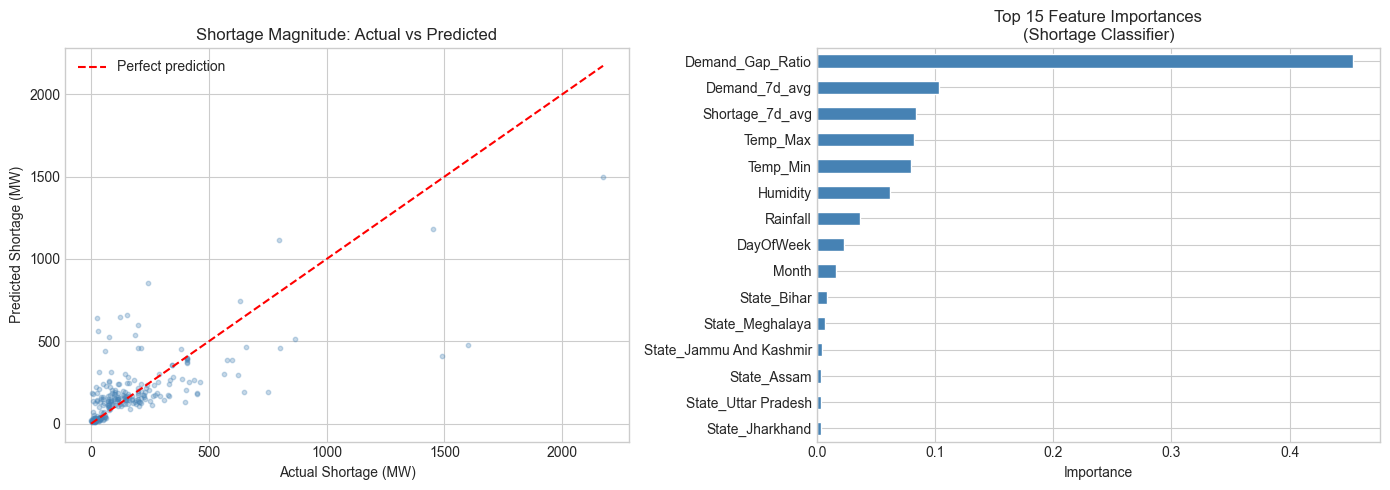

In [21]:
# ── Shortage model visualisations ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(yr_te_pos, yr_pred_pos, alpha=0.3, s=10, color='steelblue')
lim = max(float(yr_te_pos.max()), float(yr_pred_pos.max()))
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Shortage (MW)')
axes[0].set_ylabel('Predicted Shortage (MW)')
axes[0].set_title('Shortage Magnitude: Actual vs Predicted')
axes[0].legend()

# Feature importance (top 15)
ohe_cols    = clf_pipeline['preprocess']\
               .named_transformers_['cat']\
               .get_feature_names_out(CAT_FEATURES).tolist()
feat_names  = NUM_FEATURES + ohe_cols
importances = clf_pipeline['model'].feature_importances_
feat_imp    = (
    pd.Series(importances, index=feat_names)
      .sort_values(ascending=False)
      .head(15)
)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Feature Importances\n(Shortage Classifier)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('shortage_model_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 — Save All Artifacts
> File names here are the contract between the notebook and `predict_api_fast.py`.
> If you rename anything here, update the API paths accordingly.

In [22]:
# ── Prophet models ────────────────────────────────────────────────────────────
for state, m in prophet_models.items():
    safe_name = state.replace(' ', '_').replace('/', '-')
    path = MODELS_DIR / f'prophet_{safe_name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(m, f)

# ── Shortage models ───────────────────────────────────────────────────────────
joblib.dump(clf_pipeline, MODELS_DIR / 'shortage_classifier.joblib')
joblib.dump(reg_pipeline, MODELS_DIR / 'shortage_regressor.joblib')

# ── Feature metadata (API reads this to reconstruct input schema) ─────────────
with open(MODELS_DIR / 'shortage_features.json', 'w') as f:
    json.dump({
        'features': SHORTAGE_FEATURES,
        'num':      NUM_FEATURES,
        'cat':      CAT_FEATURES
    }, f, indent=2)

# ── Metrics ───────────────────────────────────────────────────────────────────
metrics_df.to_csv(MODELS_DIR / 'prophet_metrics.csv', index=False)
cv_summary.to_csv(MODELS_DIR / 'cv_summary.csv')

# ── Verify everything saved ───────────────────────────────────────────────────
saved = list(MODELS_DIR.iterdir())
print(f'Saved {len(saved)} artifacts to {MODELS_DIR}/')
for p in sorted(saved):
    print(f'  {p.name}')

Saved 40 artifacts to models/
  cv_summary.csv
  prophet_Andhra_Pradesh.pkl
  prophet_Arunachal_Pradesh.pkl
  prophet_Assam.pkl
  prophet_Bihar.pkl
  prophet_Chandigarh.pkl
  prophet_Chhattisgarh.pkl
  prophet_Dadra_And_Nagar_Haveli_And_Daman_And_Diu.pkl
  prophet_Delhi.pkl
  prophet_Goa.pkl
  prophet_Gujarat.pkl
  prophet_Haryana.pkl
  prophet_Himachal_Pradesh.pkl
  prophet_Jammu_And_Kashmir.pkl
  prophet_Jharkhand.pkl
  prophet_Karnataka.pkl
  prophet_Kerala.pkl
  prophet_Madhya_Pradesh.pkl
  prophet_Maharashtra.pkl
  prophet_Manipur.pkl
  prophet_Meghalaya.pkl
  prophet_metrics.csv
  prophet_Mizoram.pkl
  prophet_Nagaland.pkl
  prophet_Odisha.pkl
  prophet_Other.pkl
  prophet_Puducherry.pkl
  prophet_Punjab.pkl
  prophet_Rajasthan.pkl
  prophet_Sikkim.pkl
  prophet_Tamil_Nadu.pkl
  prophet_Telangana.pkl
  prophet_Tripura.pkl
  prophet_Uttar_Pradesh.pkl
  prophet_Uttarakhand.pkl
  prophet_West_Bengal.pkl
  shortage_classifier.joblib
  shortage_features.json
  shortage_regressor.jobli

## Section 10 — Final Summary

In [23]:
divider = '=' * 65
print(divider)
print('  WEATHER-DRIVEN ELECTRICITY DEMAND — FINAL RESULTS')
print(divider)

print('\n[1] Model Comparison (why SVR was replaced)')
print(cv_summary.to_string())

print(f'\n[2] Prophet Demand Forecast')
print(f'  States trained successfully : {len(prophet_models)}')
print(f'  States skipped (data < {PROPHET_MIN_ROWS}d)  : {len(skipped_states)}')
print(f'  Mean MAE                    : {metrics_df["MAE"].mean():.2f} MW')
print(f'  Mean RMSE                   : {metrics_df["RMSE"].mean():.2f} MW')
print(f'  Mean R²                     : {metrics_df["R2"].mean():.4f}')
print(f'  Best state (R²={metrics_df["R2"].max():.3f})  : {metrics_df.loc[metrics_df["R2"].idxmax(), "state"]}')

print(f'\n[3] Shortage Classifier (GBM)')
print(f'  ROC-AUC  : {auc:.4f}')
print(f'  Note     : 0.75–0.90 = realistic; 1.0 = leakage (now fixed)')

print(f'\n[4] Shortage Magnitude Regressor (RF)')
print(f'  MAE  : {mean_absolute_error(yr_te_pos, yr_pred_pos):.2f} MW')
print(f'  RMSE : {np.sqrt(mean_squared_error(yr_te_pos, yr_pred_pos)):.2f} MW')
print(f'  R²   : {r2_score(yr_te_pos, yr_pred_pos):.4f}')

print(f'\n[5] Artifacts saved to: {MODELS_DIR}/')
print(divider)
print('Next step: uvicorn predict_api_fast:app --reload --port 8000')

  WEATHER-DRIVEN ELECTRICITY DEMAND — FINAL RESULTS

[1] Model Comparison (why SVR was replaced)
                      R2       RMSE        MAE
model                                         
LinearRegression  0.9936   522.7733   278.9833
RandomForest      0.9545  1154.4617   578.0667
XGBoost           0.9444  1289.6550   637.9117
SVR               0.3294  5577.6250  3317.7583

[2] Prophet Demand Forecast
  States trained successfully : 34
  States skipped (data < 365d)  : 0
  Mean MAE                    : 765.26 MW
  Mean RMSE                   : 928.96 MW
  Mean R²                     : -1.1564
  Best state (R²=0.293)  : Tamil Nadu

[3] Shortage Classifier (GBM)
  ROC-AUC  : 0.9069
  Note     : 0.75–0.90 = realistic; 1.0 = leakage (now fixed)

[4] Shortage Magnitude Regressor (RF)
  MAE  : 98.50 MW
  RMSE : 182.38 MW
  R²   : 0.4985

[5] Artifacts saved to: models/
Next step: uvicorn predict_api_fast:app --reload --port 8000
